## Supermarket Sales

First 5 rows:
  Invoice_ID Branch       City Customer_Type  Gender         Product_Line  \
0  INV000001      B   Mandalay        Member    Male     Food & Beverages   
1  INV000002      C   Mandalay        Member  Female     Food & Beverages   
2  INV000003      C  Naypyitaw        Normal  Female  Fashion Accessories   
3  INV000004      B  Naypyitaw        Member  Female     Food & Beverages   
4  INV000005      C     Yangon        Normal  Female     Food & Beverages   

   Unit_Price  Quantity   Tax   Total        Date   Time      Payment  Rating  
0       69.36         3  7.28  119.58  2023-08-08  18:54  Credit card     8.4  
1       35.25         1  6.62  137.13  2023-02-09  18:44  Credit card     4.3  
2       57.56         8  4.66  490.48  2023-08-24  16:16         Cash     9.6  
3       16.60         5  8.57  142.54  2023-02-09  11:35         Cash     4.5  
4       49.07         1  3.70   24.43  2023-07-04   8:56  Credit card     5.8  

Dataset Info:
<class 'pandas.core.frame.Da

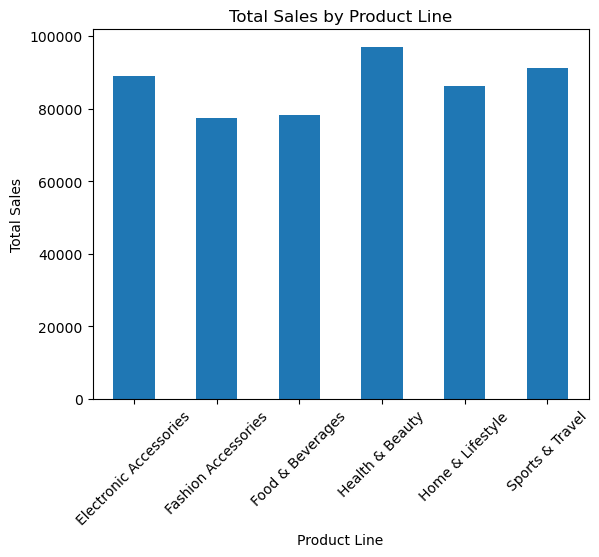

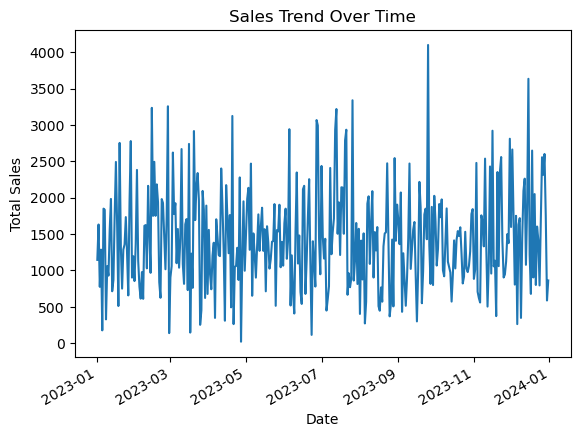

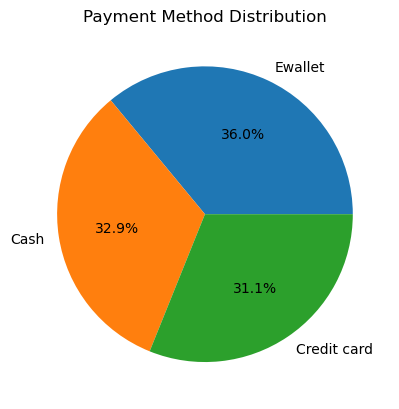


Average Rating by Branch:
Branch
A    6.923294
B    6.971983
C    6.978413
Name: Rating, dtype: float64

Total Sales by Gender:
Gender
Female    264337.27
Male      254943.42
Name: Total, dtype: float64

Correlation Matrix:
            Unit_Price  Quantity       Tax     Total    Rating
Unit_Price    1.000000  0.021547 -0.006407  0.004670 -0.013828
Quantity      0.021547  1.000000 -0.021480 -0.012459 -0.015680
Tax          -0.006407 -0.021480  1.000000 -0.004217 -0.016355
Total         0.004670 -0.012459 -0.004217  1.000000 -0.009223
Rating       -0.013828 -0.015680 -0.016355 -0.009223  1.000000


In [4]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("supermarket_sales.csv")

# -------------------------------
# BASIC EXPLORATION
# -------------------------------
print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

# Convert Date column to datetime (if exists)
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])

# -------------------------------
# GRAPH 1: Total Sales by Product Line (Bar Chart)
# -------------------------------
sales_product = df.groupby('Product_Line')['Total'].sum()

plt.figure()
sales_product.plot(kind='bar')
plt.xlabel("Product Line")
plt.ylabel("Total Sales")
plt.title("Total Sales by Product Line")
plt.xticks(rotation=45)
plt.show()

# -------------------------------
# GRAPH 2: Sales Trend Over Time (Line Chart)
# -------------------------------
if 'Date' in df.columns:
    sales_trend = df.groupby('Date')['Total'].sum()
    
    plt.figure()
    sales_trend.plot(kind='line')
    plt.xlabel("Date")
    plt.ylabel("Total Sales")
    plt.title("Sales Trend Over Time")
    plt.show()

# -------------------------------
# GRAPH 3: Payment Method Distribution (Pie Chart)
# -------------------------------
payment_counts = df['Payment'].value_counts()

plt.figure()
payment_counts.plot(kind='pie', autopct='%1.1f%%')
plt.ylabel("")  # Remove default label
plt.title("Payment Method Distribution")
plt.show()

# -------------------------------
# EXTRA ANALYSIS
# -------------------------------

# Average rating by branch
if 'Branch' in df.columns and 'Rating' in df.columns:
    avg_rating = df.groupby('Branch')['Rating'].mean()
    print("\nAverage Rating by Branch:")
    print(avg_rating)

# Total sales by gender
if 'Gender' in df.columns:
    sales_gender = df.groupby('Gender')['Total'].sum()
    print("\nTotal Sales by Gender:")
    print(sales_gender)

# Correlation matrix
print("\nCorrelation Matrix:")
print(df.corr(numeric_only=True))